In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [23]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [24]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

In [25]:
tf.test.is_built_with_cuda()

True

In [26]:
from tensorflow.keras.datasets import cifar10
(X_train, y_train), (X_test,y_test) = cifar10.load_data() 

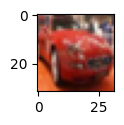

In [28]:
plt.figure(figsize=(10,1))
plt.imshow(X_train[5])


In [29]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [32]:
X_train = X_train/255
X_test = X_test/255

In [30]:
y_train_categorical = keras.utils.to_categorical(y_train,num_classes=10)
y_test_categorical = keras.utils.to_categorical(y_test,num_classes=10)

In [53]:
def get_model():
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=(32,32,3)),
        keras.layers.Dense(3500,activation='relu'),
        keras.layers.Dense(1500, activation='relu'),
        keras.layers.Dense(10,activation='sigmoid'),
    ])
    model.compile(optimizer='SGD',loss='categorical_crossentropy',metrics=['accuracy'])
    return model

In [35]:
model = get_model()
model.fit(X_train,y_train_categorical,epochs=50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4190 - loss: 1.6398
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4556 - loss: 1.5473
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4787 - loss: 1.4801
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5008 - loss: 1.4246
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5118 - loss: 1.3870
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5260 - loss: 1.3458
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5426 - loss: 1.3072
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5521 - loss: 1.2788
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5696 - loss: 1.2319
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5746 - loss: 1.2162
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5883 - loss: 1.1862
Epoch 12/50
1563/1563 ━━━━━━━━

In [54]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
    model = get_model()
    model.fit(X_train,y_train_categorical,epochs=1)

I0000 00:00:1764016246.785265      95 service.cc:148] XLA service 0x78ef78076e30 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764016246.785304      95 service.cc:156]   StreamExecutor device (0): Host, Default Version


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 98s 62ms/step - accuracy: 0.3032 - loss: 1.9258
1min 39s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [55]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
    model = get_model()
    model.fit(X_train,y_train_categorical,epochs=1)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3072 - loss: 1.9255
8.83 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [57]:
%%timeit -n1 -r1
with tf.device('/GPU:1'):
    model = get_model()
    model.fit(X_train,y_train_categorical,epochs=1)

I0000 00:00:1764016403.874122      95 cuda_dnn.cc:529] Loaded cuDNN version 90300


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3054 - loss: 1.9269
9.74 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [39]:
index = np.argmax(model.predict(X_test)[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [43]:
print(classes[index])
print(classes[y_test[0][0]])

cat
cat


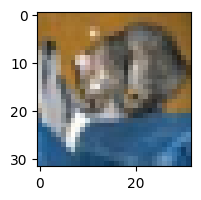

In [49]:
plt.figure(figsize=(10,2))
plt.imshow(X_test[0])